In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv("ToyotaCorolla - MLR.csv")

In [25]:
df.sample(5)

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
368,11450,37,21500,Petrol,110,0,1600,5,4,5,1030
619,7350,65,140168,Diesel,72,0,2000,3,4,5,1115
1374,8600,69,57096,Petrol,86,0,1300,3,4,5,1025
284,11950,41,45287,Petrol,110,0,1600,5,4,5,1075
563,12950,51,38403,Petrol,110,0,1600,3,4,5,1055


In [26]:
#here our target is this Price

In [27]:
df.shape


(1436, 11)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [29]:
#Most of the data we have numeric data
#from this info i guess we dont have any missing values

In [30]:
df.isnull().sum() #Yes we dont have any missing values in this data 

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Categorical data analysis

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

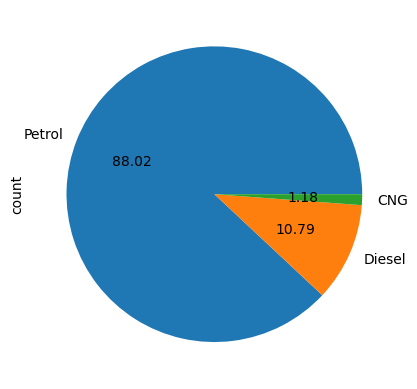

In [31]:
df.Fuel_Type.value_counts().plot(kind='pie',autopct="%.2f") #we 3 types of fuels
df.Fuel_Type.value_counts() 
#In the data we have more petrol vehicles

I guess one column name is miss spelled Age_08_04	
i need to change this name of this column to Age

In [32]:
df.rename(columns={'Age_08_04':'Age'},inplace=True)

My target variable is price so i would like to chek the relationship between this price feature with other features to get to know is there any relationship or 

i will do that using this scatterplot


<Axes: xlabel='Age', ylabel='Price'>

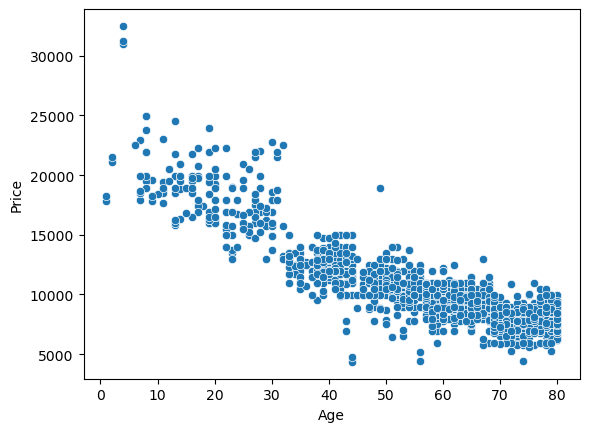

In [33]:
sns.scatterplot(x="Age",y="Price",data=df)

In [34]:
df["Age"].corr(df["Price"])
#here we can see this strong negative relation

np.float64(-0.8765904971436395)

i can see that in this comparision between this age and price that
When age is increasing then price is decreasing even through it is a negative relation its fine
here we have strong negative relation between this age and price

<Axes: xlabel='KM', ylabel='Price'>

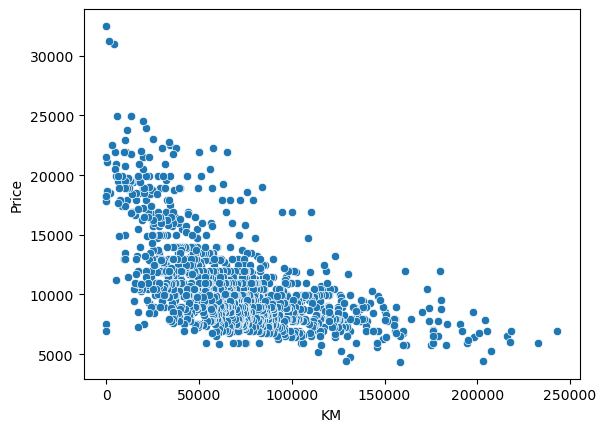

In [35]:
sns.scatterplot(x="KM",y="Price",data=df)

In [36]:
df["KM"].corr(df["Price"])
#Here we have moderate negative relation 

np.float64(-0.5699601645337193)

From the above graph i can see that there is some relation because the price is decreasinf as the kilometers are increasing.

In [37]:
df.columns

Index(['Price', 'Age', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')

<Axes: xlabel='Fuel_Type', ylabel='Price'>

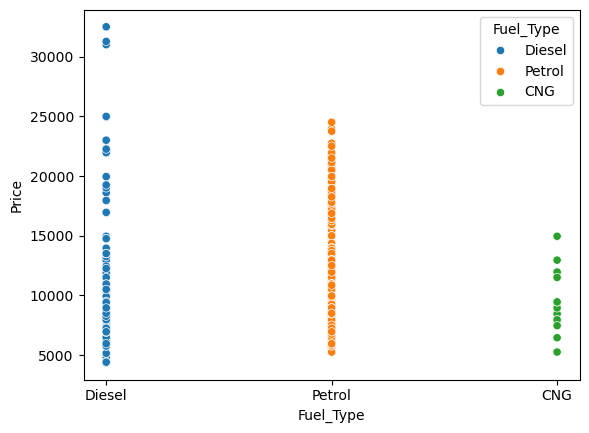

In [38]:
sns.scatterplot(x="Fuel_Type",y="Price",data=df,hue="Fuel_Type")
#we have to encode this Fuel_type

np.float64(0.314989829640036)

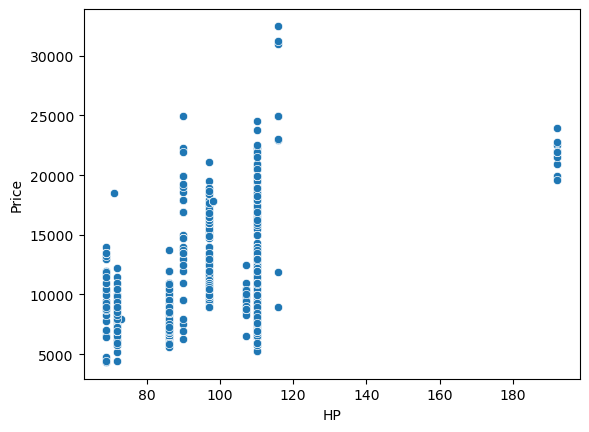

In [39]:
sns.scatterplot(x='HP',y='Price',data=df)
df["HP"].corr(df["Price"])
#

Iam going to encode this Fuel_Type using this one hot encoding because the data we have in this Fuel_TYpe col is nomianl data

In [ ]:
df=pd.get_dummies(df,columns=['Fuel_Type'],drop_first=True)
#we must drop this first col after using this one hot encoding
#this splits this fule type col to guel type desiel,Fuel type petrol and Fuel type cng
#if we just keep them like this then we are going to have this multicollineariy between these cols so we are going to drop this first col and other reason is this desiel fuel type is going to be a refrence for example if a row is having both 0s for fuel_type petrol and cng then that must be desiel type vehicle this is how it gets works in backend of python

In [41]:
df.corr()['Price']

Price               1.000000
Age                -0.876590
KM                 -0.569960
HP                  0.314990
Automatic           0.033081
cc                  0.126389
Doors               0.185326
Cylinders                NaN
Gears               0.063104
Weight              0.581198
Fuel_Type_Diesel    0.054084
Fuel_Type_Petrol   -0.038516
Name: Price, dtype: float64

Hm i got this Cylinders as NaN because we have same data in this whole col
so iam dropping it

In [ ]:
df.drop(columns=['Cylinders'],inplace=True) #dropped this cylinders col

iam checking for multi collinearity

In [44]:
df[["Age","KM","HP","Weight","cc","Doors","Gears"]].corr()


,Age,KM,HP,Weight,cc,Doors,Gears
Age,1.000000,0.505672,-0.156622,-0.470253,-0.098084,-0.148359,-0.005364
KM,0.505672,1.000000,-0.333538,-0.028598,0.102683,-0.036197,0.015023
HP,-0.156622,-0.333538,1.000000,0.089614,0.035856,0.092424,0.209477
Weight,-0.470253,-0.028598,0.089614,1.000000,0.335637,0.302618,0.020613
cc,-0.098084,0.102683,0.035856,0.335637,1.000000,0.079903,0.014629
Doors,-0.148359,-0.036197,0.092424,0.302618,0.079903,1.000000,-0.160141
Gears,-0.005364,0.015023,0.209477,0.020613,0.014629,-0.160141,1.000000


<Axes: xlabel='cc', ylabel='Price'>

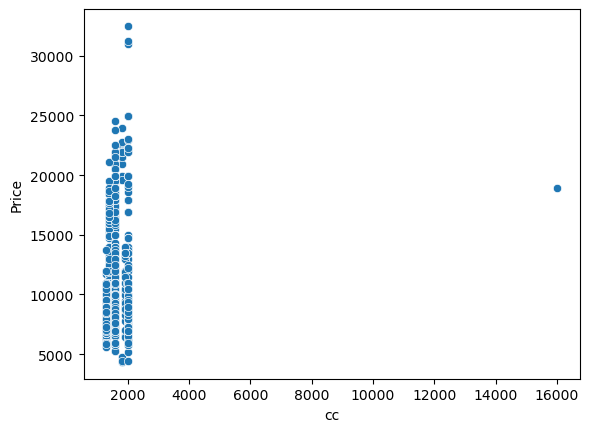

In [ ]:
sns.scatterplot(x="cc",y='Price',data=df) #woo we have a vechile that which is having a cc grater than 160000
#This need to be dropped if we are going to use this cc for model bulind and this 
#This automatic is have very low correlation with price i mean < 0.1 and
#same for this Gears and fuel types as well
#They dont have any linear relation ship so iam thinking to drop them because their relation with the target varibale is < 0.1


<Axes: xlabel='Gears', ylabel='Price'>

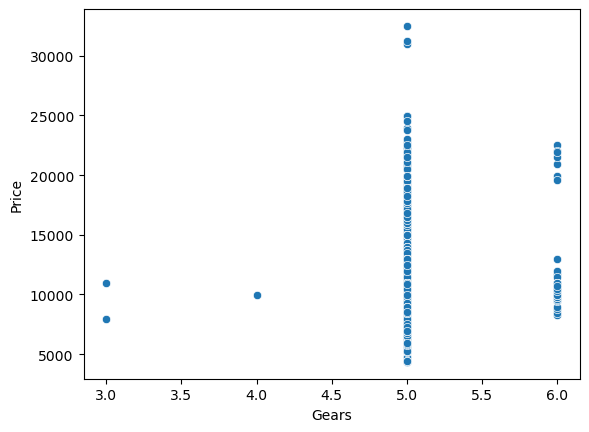

In [47]:
sns.scatterplot(x="Gears",y='Price',data=df)